# **Waze Project**
**Course 4 - The Power of Statistics**

Your team is nearing the midpoint of their user churn project. So far, you’ve completed a project proposal, and used Python to explore and analyze Waze’s user data. You’ve also used Python to create data visualizations. The next step is to use statistical methods to analyze and interpret your data.

You receive a new email from Sylvester Esperanza, your project manager. Sylvester tells your team about a new request from leadership: to analyze the relationship between mean amount of rides and device type. You also discover follow-up emails from three other team members: May Santner, Chidi Ga, and Harriet Hadzic. These emails discuss the details of the analysis. They would like a statistical analysis of ride data based on device type. In particular, leadership wants to know if there is a statistically significant difference in mean amount of rides between iPhone® users and Android™ users. A final email from Chidi includes your specific assignment: to conduct a two-sample hypothesis test (t-test) to analyze the difference in the mean amount of rides between iPhone users and Android users.

A notebook was structured and prepared to help you in this project. Please complete the following questions and prepare an executive summary.

# **Course 4 End-of-course project: Data exploration and hypothesis testing**

In this activity, you will explore the data provided and conduct a hypothesis test.
<br/>

**The purpose** of this project is to demostrate knowledge of how to conduct a two-sample hypothesis test.

**The goal** is to apply descriptive statistics and hypothesis testing in Python.
<br/>

*This activity has three parts:*

**Part 1:** Imports and data loading
* What data packages will be necessary for hypothesis testing?

**Part 2:** Conduct hypothesis testing
* How did computing descriptive statistics help you analyze your data?

* How did you formulate your null hypothesis and alternative hypothesis?

**Part 3:** Communicate insights with stakeholders

* What key business insight(s) emerged from your hypothesis test?

* What business recommendations do you propose based on your results?

<br/>


Follow the instructions and answer the questions below to complete the activity. Then, you will complete an Executive Summary using the questions listed on the PACE Strategy Document.

Be sure to complete this activity before moving on. The next course item will provide you with a completed exemplar to compare to your own work.



# **Data exploration and hypothesis testing**

<img src="images/Pace.png" width="100" height="100" align=left>

# **PACE stages**

Throughout these project notebooks, you'll see references to the problem-solving framework PACE. The following notebook components are labeled with the respective PACE stage: Plan, Analyze, Construct, and Execute.

<img src="images/Plan.png" width="100" height="100" align=left>


## **PACE: Plan**

Consider the questions in your PACE Strategy Document and those below to craft your response:
1. What is your research question for this data project? Later on, you will need to formulate the null and alternative hypotheses as the first step of your hypothesis test. Consider your research question now, at the start of this task.


**Research question:**

"Do drivers who open the application using an iPhone have the same number of drives on average as drivers who use Android devices?"

### **Task 1. Imports and data loading**

Import packages and libraries needed to compute descriptive statistics and conduct a hypothesis test.

<details>
  <summary><h4><strong>Hint:</strong></h4></summary>

Before you begin, recall the following Python packages and functions:

*Main functions*: stats.ttest_ind(a, b, equal_var)

*Other functions*: mean()

*Packages*: pandas, stats.scipy

</details>

In [15]:
# Import any relevant packages or libraries
import pandas as pd
from scipy import stats
import numpy as np

Import the dataset.


In [16]:
#pip install imblearn

In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.under_sampling import RandomUnderSampler
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('waze_dataset.csv')

# Drop ID column and convert label to binary
df1 = df.drop('ID', axis=1)
df1['label'] = np.where(df1['label'] == 'retained', 1, 0)

# Check data types and identify categorical columns
print("Data types:")
print(df1.dtypes)
print(f"\nNumber of categorical columns: {len(df1.select_dtypes(include=['object']).columns)}")

# Identify categorical columns
categorical_cols = df1.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {categorical_cols}")

# Handle categorical variables - using Label Encoding
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df1[col] = le.fit_transform(df1[col].astype(str))
    label_encoders[col] = le
    print(f"Encoded {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Check class distribution
print("\nOriginal class distribution:")
print(df1['label'].value_counts())
print(f"Percentage of retained (1): {df1['label'].mean():.2%}")

# Split into features and target
X = df1.drop('label', axis=1)
y = df1['label']


Data types:
label                        int64
sessions                     int64
drives                       int64
total_sessions             float64
n_days_after_onboarding      int64
total_navigations_fav1       int64
total_navigations_fav2       int64
driven_km_drives           float64
duration_minutes_drives    float64
activity_days                int64
driving_days                 int64
device                      object
dtype: object

Number of categorical columns: 1
Categorical columns: ['device']
Encoded device: {'Android': 0, 'iPhone': 1}

Original class distribution:
1    11763
0     3236
Name: label, dtype: int64
Percentage of retained (1): 78.43%


<Figure size 864x720 with 0 Axes>

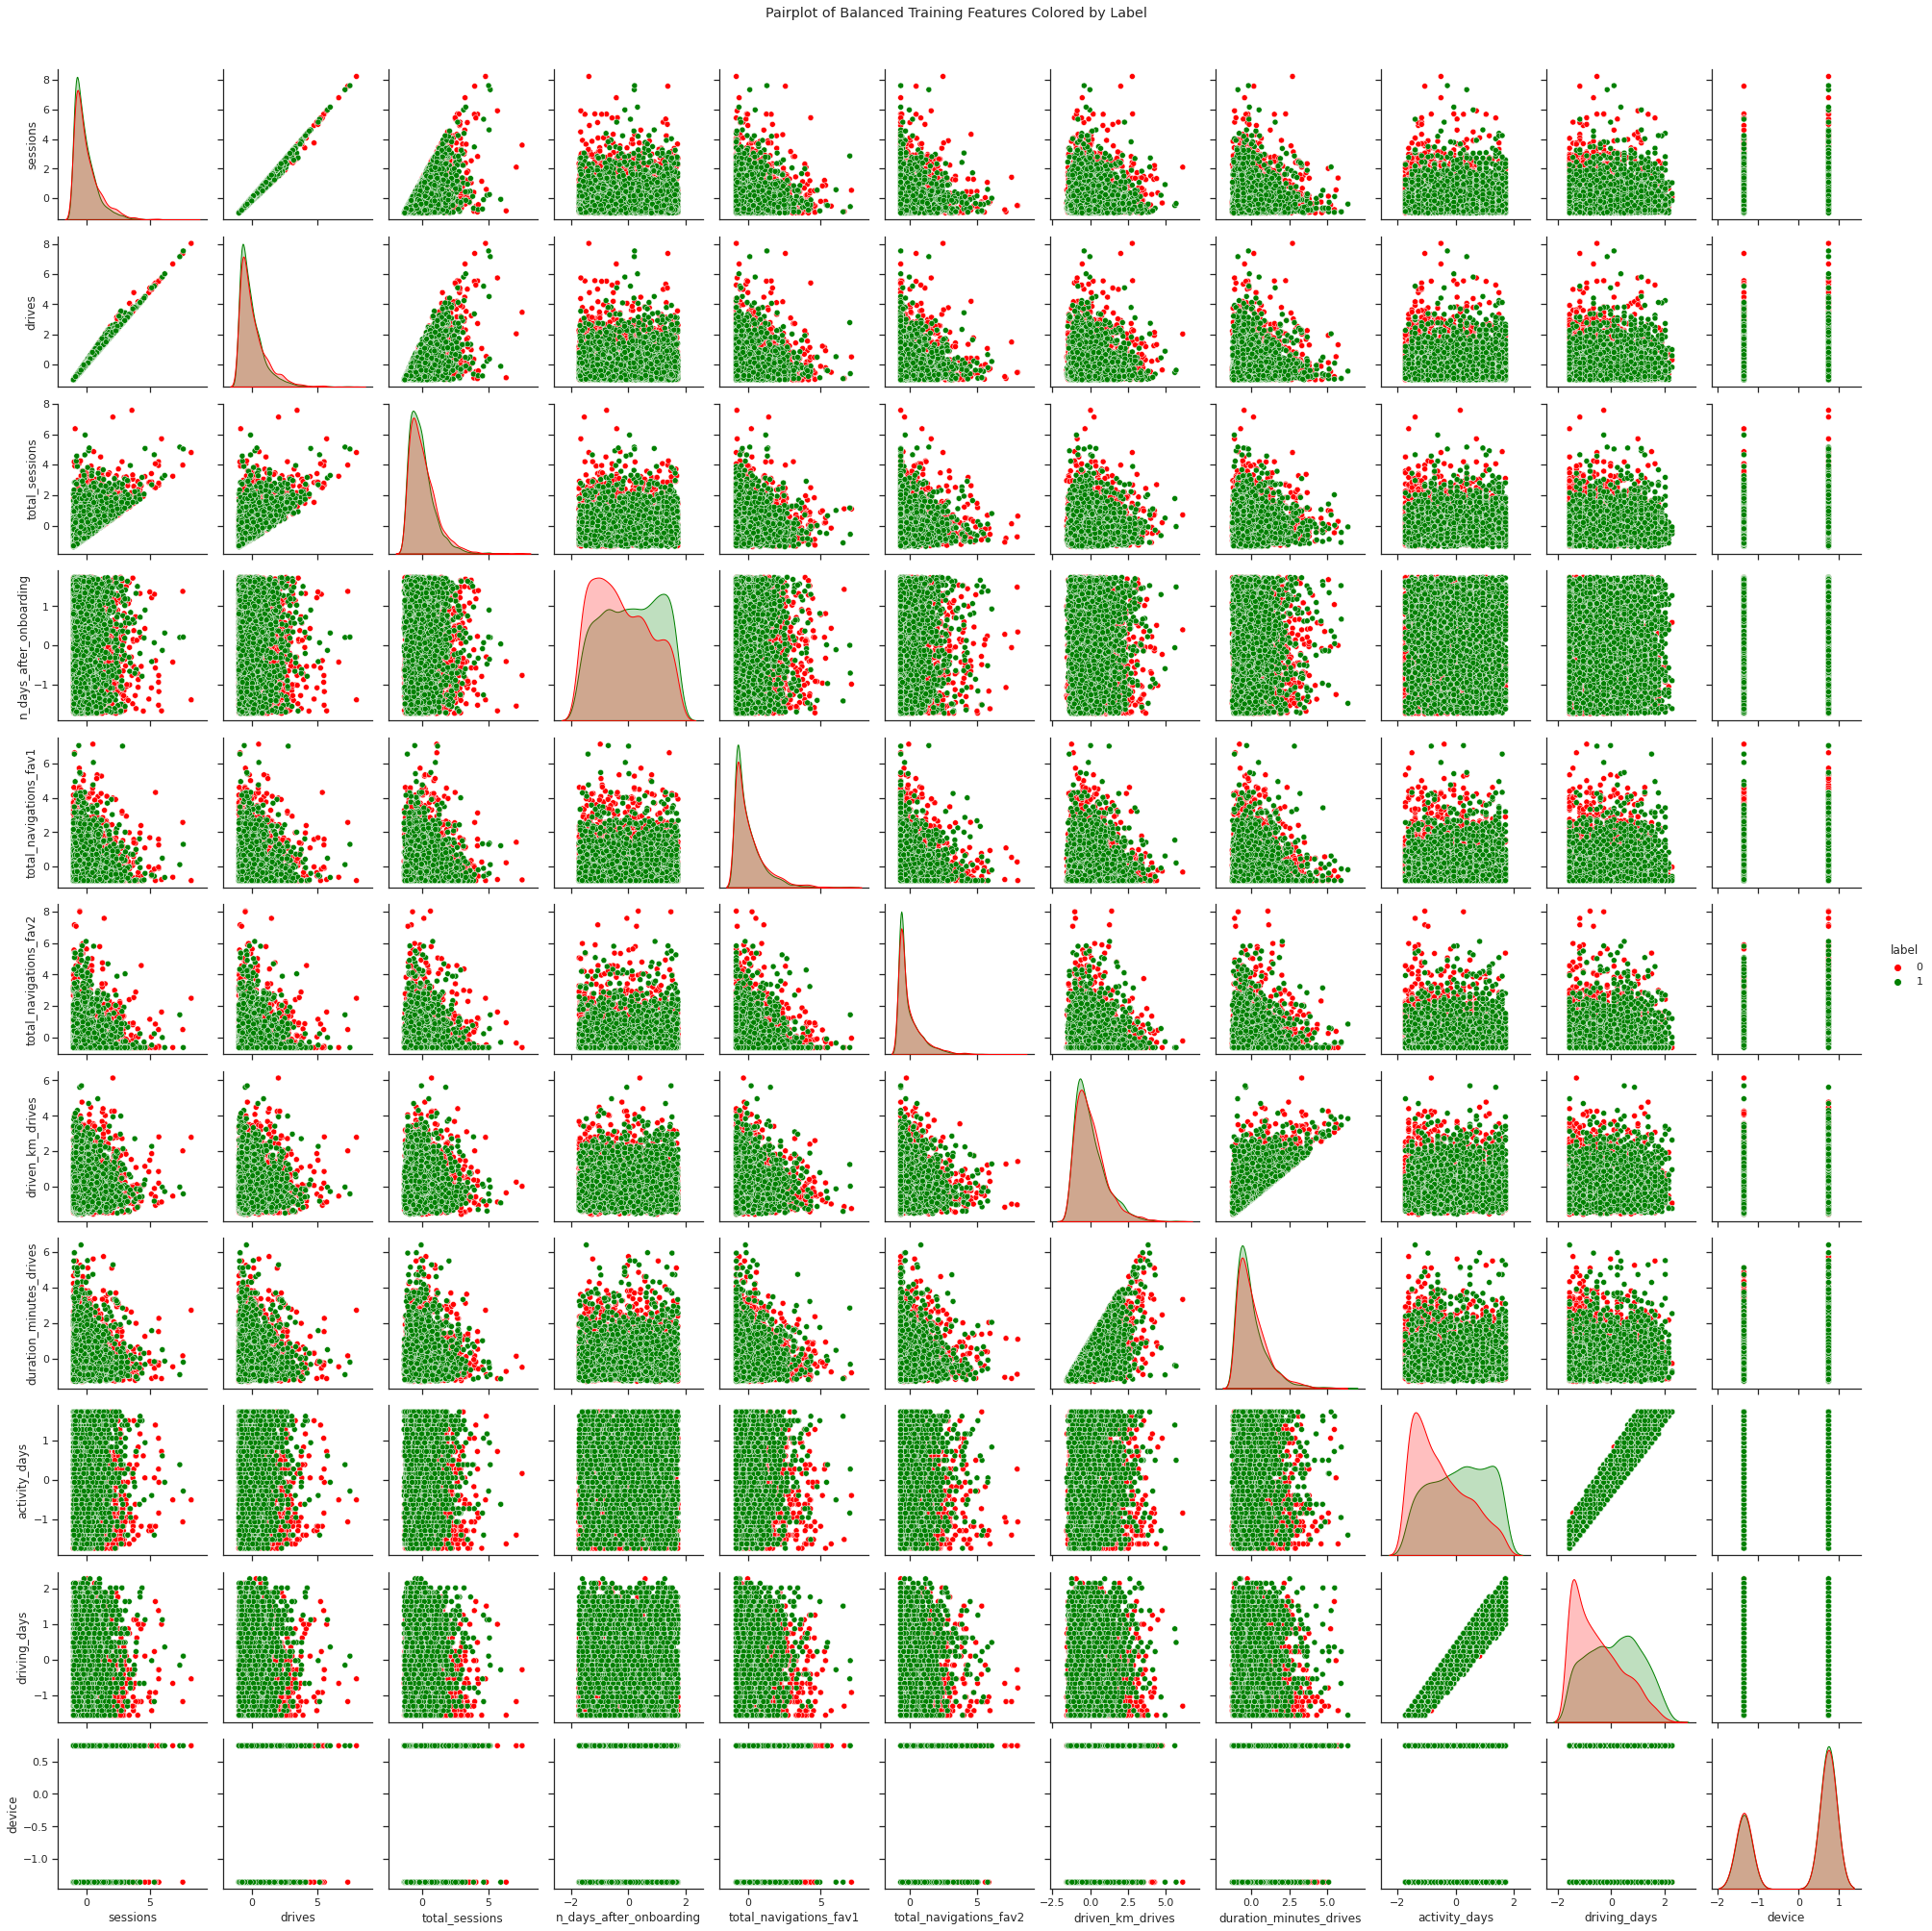

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Example train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply Random Under Sampling
rus = RandomUnderSampler(random_state=42)
X_train_balanced, y_train_balanced = rus.fit_resample(X_train_scaled, y_train)

# Convert back to DataFrame for plotting
X_train_balanced_df = pd.DataFrame(X_train_balanced, columns=X.columns)
X_train_balanced_df['label'] = y_train_balanced.values

# Plot pairplot
sns.set(style="ticks")
plt.figure(figsize=(12, 10))
sns.pairplot(X_train_balanced_df, hue='label', palette={0:'red', 1:'green'}, diag_kind='kde')
plt.suptitle("Pairplot of Balanced Training Features Colored by Label", y=1.02)
plt.show()


## Lets Balance the Classs



In [21]:
rus = RandomUnderSampler(random_state=42)
X_train_balanced, y_train_balanced = rus.fit_resample(X_train_scaled, y_train)

unique, counts = np.unique(y_train_balanced, return_counts=True)
class_distribution = dict(zip(unique, counts))
print("Class distribution after Random Under Sampling:")
print(class_distribution)

Class distribution after Random Under Sampling:
{0: 2589, 1: 2589}



Train set shape: (11999, 11)
Test set shape: (3000, 11)
Train class distribution:
1    9410
0    2589
Name: label, dtype: int64

After Random Under Sampling (Train set):
Balanced train set shape: (5178, 11)
Balanced class distribution:
{0: 2589, 1: 2589}

After Random Under Sampling (Test set):
Balanced test set shape: (1294, 11)
Balanced class distribution:
{0: 647, 1: 647}

Model Evaluation (Balanced Test Set):
Accuracy: 0.6723
ROC AUC: 0.7189

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.68      0.67       647
           1       0.67      0.67      0.67       647

    accuracy                           0.67      1294
   macro avg       0.67      0.67      0.67      1294
weighted avg       0.67      0.67      0.67      1294


Confusion Matrix:
[[439 208]
 [216 431]]


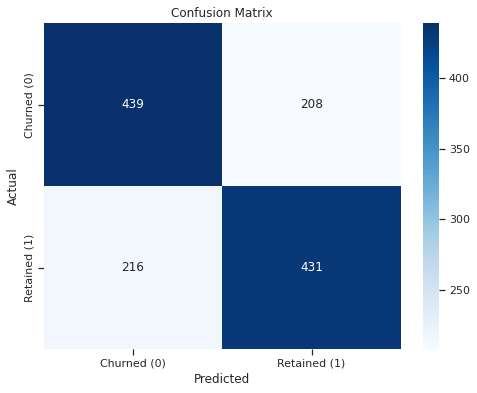

In [22]:
from imblearn.under_sampling import RandomUnderSampler

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,stratify=y
)

print(f"\nTrain set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print("Train class distribution:")
print(y_train.value_counts())

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Balance the train set using undersampling
rus = RandomUnderSampler(random_state=42)
X_train_balanced, y_train_balanced = rus.fit_resample(X_train_scaled, y_train)

print(f"\nAfter Random Under Sampling (Train set):")
print(f"Balanced train set shape: {X_train_balanced.shape}")
print("Balanced class distribution:")
unique, counts = np.unique(y_train_balanced, return_counts=True)
print(dict(zip(unique, counts)))

rus = RandomUnderSampler(random_state=42)
X_test_balanced, y_test_balanced = rus.fit_resample(X_test_scaled, y_test)

print(f"\nAfter Random Under Sampling (Test set):")
print(f"Balanced test set shape: {X_test_balanced.shape}")
print("Balanced class distribution:")
unique, counts = np.unique(y_test_balanced, return_counts=True)
print(dict(zip(unique, counts)))

# Train logistic regression
log_reg = LogisticRegression(
    penalty='l2',
    C=10,
    solver='liblinear',
    random_state=42,
    max_iter=1000
)
log_reg.fit(X_train_balanced, y_train_balanced)

# Make predictions on balanced test set
y_pred = log_reg.predict(X_test_balanced)
y_pred_proba = log_reg.predict_proba(X_test_balanced)[:, 1]

# Evaluate the model
print("\nModel Evaluation (Balanced Test Set):")
print(f"Accuracy: {accuracy_score(y_test_balanced, y_pred):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test_balanced, y_pred_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_balanced, y_pred))
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test_balanced, y_pred)
print(cm)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Churned (0)', 'Retained (1)'], 
            yticklabels=['Churned (0)', 'Retained (1)'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


<img src="images/Analyze.png" width="100" height="100" align=left>

<img src="images/Construct.png" width="100" height="100" align=left>

## **PACE: Analyze and Construct**

Consider the questions in your PACE Strategy Document and those below to craft your response:
1. Data professionals use descriptive statistics for exploratory data analysis (EDA). How can computing descriptive statistics help you learn more about your data in this stage of your analysis?


**Answer:**

In general, descriptive statistics are useful because they let you quickly explore and understand large amounts of data. In this case, computing descriptive statistics helps you quickly compare the average amount of drives by device type.


### **Task 2. Data exploration**

Use descriptive statistics to conduct exploratory eata analysis (EDA).


<details>
  <summary><h4><strong>Hint:</strong></h4></summary>

Refer back to *Self Review Descriptive Statistics* for this step-by-step process.

</details>

**Note:** In the dataset, `device` is a categorical variable with the labels `iPhone` and `Android`.

In order to perform this analysis, you must turn each label into an integer.  The following code assigns a `1` for an `iPhone` user and a `2` for `Android`.  It assigns this label back to the variable `device_type`.

**Note:** Creating a new variable is ideal so that you don't overwrite original data.



1. Create a dictionary called `map_dictionary` that contains the class labels (`'Android'` and `'iPhone'`) for keys and the values you want to convert them to (`2` and `1`) as values.

2. Create a new column called `device_type` that is a copy of the `device` column.

3. Use the [`map()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.map.html#pandas-series-map) method on the `device_type` series. Pass `map_dictionary` as its argument. Reassign the result back to the `device_type` series.
</br></br>
When you pass a dictionary to the `Series.map()` method, it will replace the data in the series where that data matches the dictionary's keys. The values that get imputed are the values of the dictionary.

```
Example:
df['column']
```

|column |
|  :-:       |
| A     |
| B     |
| A     |
| B     |

```
map_dictionary = {'A': 2, 'B': 1}
df['column'] = df['column'].map(map_dictionary)
df['column']
```

|column |
|  :-: |
| 2    |
| 1    |
| 2    |
| 1    |


In [3]:
# 1. Create `map_dictionary`
map_dictionary = {'Android': 2, 'iPhone': 1}

# 2. Create new `device_type` column
df['device_type'] = df['device']

# 3. Map the new column to the dictionary
df['device_type'] = df['device_type'].map(map_dictionary)

df['device_type'].head()

0    2
1    1
2    2
3    1
4    2
Name: device_type, dtype: int64

You are interested in the relationship between device type and the number of drives. One approach is to look at the average number of drives for each device type. Calculate these averages.

In [4]:
df.groupby('device_type')['drives'].mean()

device_type
1    67.859078
2    66.231838
Name: drives, dtype: float64

Based on the averages shown, it appears that drivers who use an iPhone device to interact with the application have a higher number of drives on average. However, this difference might arise from random sampling, rather than being a true difference in the number of drives. To assess whether the difference is statistically significant, you can conduct a hypothesis test.


### **Task 3. Hypothesis testing**



Your goal is to conduct a two-sample t-test. Recall the steps for conducting a hypothesis test:


1.   State the null hypothesis and the alternative hypothesis
2.   Choose a signficance level
3.   Find the p-value
4.   Reject or fail to reject the null hypothesis

**Note:** This is a t-test for two independent samples. This is the appropriate test since the two groups are independent (Android users vs. iPhone users).

Recall the difference between the null hypothesis ($H_0$) and the alternative hypothesis ($H_A$).

**Question:** What are your hypotheses for this data project?


**Hypotheses:**

$H_0$: There is no difference in average number of drives between drivers who use iPhone devices and drivers who use Androids.

$H_A$: There is a difference in average number of drives between drivers who use iPhone devices and drivers who use Androids.

Next, choose 5% as the significance level and proceed with a two-sample t-test.

You can use the `stats.ttest_ind()` function to perform the test.


**Technical note**: The default for the argument `equal_var` in `stats.ttest_ind()` is `True`, which assumes population variances are equal. This equal variance assumption might not hold in practice (that is, there is no strong reason to assume that the two groups have the same variance); you can relax this assumption by setting `equal_var` to `False`, and `stats.ttest_ind()` will perform the unequal variances $t$-test (known as Welch's `t`-test). Refer to the [scipy t-test documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html) for more information.


1. Isolate the `drives` column for iPhone users.
2. Isolate the `drives` column for Android users.
3. Perform the t-test

In [5]:
# 1. Isolate the `drives` column for iPhone users.
iPhone = df[df['device_type'] == 1]['drives']

# 2. Isolate the `drives` column for Android users.
Android = df[df['device_type'] == 2]['drives']

# 3. Perform the t-test
stats.ttest_ind(a=iPhone, b=Android, equal_var=False)

Ttest_indResult(statistic=1.4635232068852353, pvalue=0.1433519726802059)

**Question:** Based on the p-value you got above, do you reject or fail to reject the null hypothesis?

> *Since the p-value is larger than the chosen significance level (5%), you fail to reject the null hypothesis. You conclude that there is **not** a statistically significant difference in the average number of drives between drivers who use iPhones and drivers who use Androids.*

<img src="images/Execute.png" width="100" height="100" align=left>

## **PACE: Execute**

Consider the questions in your PACE Strategy Document to reflect on the Execute stage.

### **Task 4: Communicate insights with stakeholders**

Now that you've completed your hypothesis test, the next step is to share your findings with the Waze leadership team. Consider the following question as you prepare to write your executive summary:

* What business insight(s) can you draw from the result of your hypothesis test?

> *The key business insight is that drivers who use iPhone devices on average have a similar number of drives as those who use Androids.*

> *One potential next step is to explore what other factors influence the variation in the number of drives, and run additonal hypothesis tests to learn more about user behavior. Further, temporary changes in marketing or user interface for the Waze app may provide more data to investigate churn.*

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged.